# 🎯 Options Pricing Engine
**Build**: Black-Scholes pricer → Greeks → Implied Vol surface.

Used at: Jane Street, Optiver, Akuna Capital

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq

# ── Black-Scholes Core ──────────────────────────────────────────────────────
def bs_price(S, K, T, r, sigma, flag='C'):
    """Black-Scholes price. flag: 'C'=call, 'P'=put."""
    if T <= 0: return max(0, (S-K) if flag=='C' else (K-S))
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    if flag == 'C':
        return S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
    else:
        return K*np.exp(-r*T)*norm.cdf(-d2) - S*norm.cdf(-d1)

# ── Greeks ──────────────────────────────────────────────────────────────────
def greeks(S, K, T, r, sigma, flag='C'):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    sign = 1 if flag=='C' else -1
    delta = sign * norm.cdf(sign * d1)
    gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
    vega  = S * norm.pdf(d1) * np.sqrt(T) / 100   # per 1% vol move
    theta = (-(S*norm.pdf(d1)*sigma)/(2*np.sqrt(T))
             - sign*r*K*np.exp(-r*T)*norm.cdf(sign*d2)) / 365
    rho   = sign * K * T * np.exp(-r*T) * norm.cdf(sign*d2) / 100
    return dict(delta=delta, gamma=gamma, vega=vega, theta=theta, rho=rho)

# Demo
S,K,T,r,sigma = 100, 100, 0.5, 0.05, 0.20
call = bs_price(S,K,T,r,sigma,'C')
put  = bs_price(S,K,T,r,sigma,'P')
print(f'ATM Call: ${call:.4f}  |  ATM Put: ${put:.4f}')
print('Greeks:', greeks(S,K,T,r,sigma,'C'))

ATM Call: $6.8887  |  ATM Put: $4.4197
Greeks: {'delta': np.float64(0.5977344689084383), 'gamma': np.float64(0.027358658565220986), 'vega': np.float64(0.2735865856522099), 'theta': np.float64(-0.022235527749869474), 'rho': np.float64(0.264423591565816)}


## Put-Call Parity Check

In [2]:
# C - P = S - K*e^(-rT)
lhs = call - put
rhs = S - K*np.exp(-r*T)
print(f'C - P = {lhs:.4f}  |  S - PV(K) = {rhs:.4f}  |  Diff = {abs(lhs-rhs):.2e}')

C - P = 2.4690  |  S - PV(K) = 2.4690  |  Diff = 7.11e-15


## Implied Volatility via Brent's Method

In [3]:
def implied_vol(market_price, S, K, T, r, flag='C', tol=1e-6):
    """Invert BS to find sigma given market price."""
    intrinsic = max(0, (S-K) if flag=='C' else (K-S))
    if market_price <= intrinsic + 1e-8:
        return np.nan
    f = lambda sig: bs_price(S, K, T, r, sig, flag) - market_price
    try:
        return brentq(f, 1e-6, 10.0, xtol=tol)
    except:
        return np.nan

# Verify round-trip
iv = implied_vol(call, S, K, T, r, 'C')
print(f'True sigma: {sigma:.4f}  |  Implied sigma: {iv:.4f}  |  Error: {abs(sigma-iv):.2e}')

True sigma: 0.2000  |  Implied sigma: 0.2000  |  Error: 1.84e-09


## Implied Volatility Surface
Simulate a vol surface with typical skew + term structure.

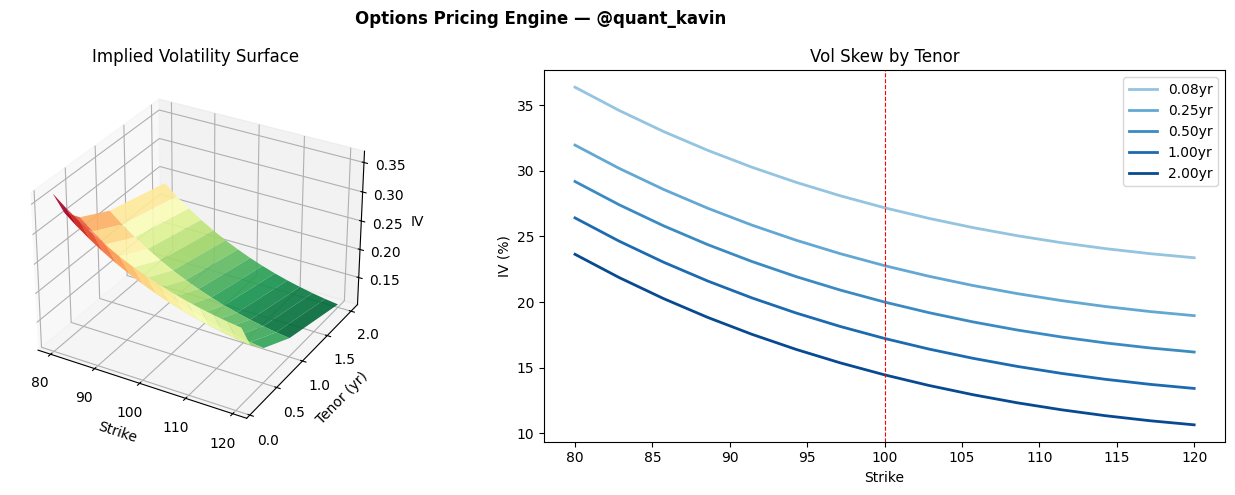

In [4]:
strikes  = np.linspace(80, 120, 15)
tenors   = [0.083, 0.25, 0.5, 1.0, 2.0]  # 1m,3m,6m,1y,2y

# Synthetic IV surface: skew + smile + term structure
def synthetic_iv(K, T, S=100, atm_vol=0.20):
    moneyness = np.log(K/S)
    skew  = -0.3 * moneyness           # negative skew
    smile =  0.5 * moneyness**2        # smile curvature
    term  = -0.04 * np.log(T / 0.5)   # flatter at longer tenors
    return atm_vol + skew + smile + term

IV = np.array([[synthetic_iv(K, T) for K in strikes] for T in tenors])

fig = plt.figure(figsize=(14, 5))

# 3D surface
ax1 = fig.add_subplot(121, projection='3d')
KK, TT = np.meshgrid(strikes, tenors)
ax1.plot_surface(KK, TT, IV, cmap='RdYlGn_r', edgecolor='none', alpha=0.9)
ax1.set_xlabel('Strike'); ax1.set_ylabel('Tenor (yr)'); ax1.set_zlabel('IV')
ax1.set_title('Implied Volatility Surface')

# 2D skew slices
ax2 = fig.add_subplot(122)
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(tenors)))
for i, T in enumerate(tenors):
    ax2.plot(strikes, IV[i]*100, color=colors[i], label=f'{T:.2f}yr', linewidth=2)
ax2.set_xlabel('Strike'); ax2.set_ylabel('IV (%)')
ax2.set_title('Vol Skew by Tenor'); ax2.legend()
ax2.axvline(100, color='red', linestyle='--', linewidth=0.8, label='ATM')

plt.suptitle('Options Pricing Engine — @quant_kavin', fontweight='bold')
plt.tight_layout()
plt.savefig('/tmp/options.png', dpi=150, bbox_inches='tight')
plt.show()

## Greeks P&L Attribution

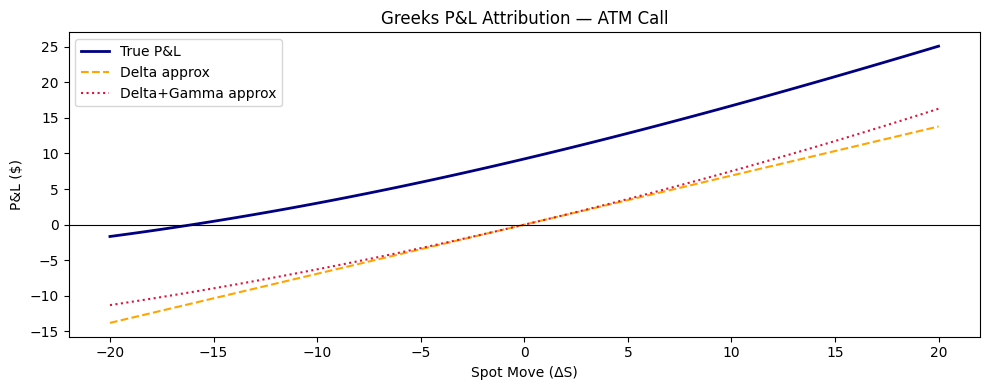

Done.


In [5]:
# Show how delta/gamma/vega explain P&L over a range of spot moves
dS_range = np.linspace(-20, 20, 100)
g = greeks(S, K, T, r, sigma, 'C')

true_pnl   = [bs_price(S+dS, K, T, r, sigma, 'C') - call for dS in dS_range]
delta_pnl  = [g['delta'] * dS for dS in dS_range]
gamma_pnl  = [g['delta']*dS + 0.5*g['gamma']*dS**2 for dS in dS_range]

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(dS_range, true_pnl,  'navy',    linewidth=2,   label='True P&L')
ax.plot(dS_range, delta_pnl, 'orange',  linestyle='--', label='Delta approx')
ax.plot(dS_range, gamma_pnl, 'crimson', linestyle=':',  label='Delta+Gamma approx')
ax.set_xlabel('Spot Move (ΔS)'); ax.set_ylabel('P&L ($)')
ax.set_title('Greeks P&L Attribution — ATM Call'); ax.legend(); ax.axhline(0, color='black', lw=0.8)
plt.tight_layout(); plt.show()
print('Done.')